# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current directory:
/content

Files here:
['.config', 'sample_data']


In [2]:
!git clone https://github.com/06sushmita/flyrank-ML-Internship.git

Cloning into 'flyrank-ML-Internship'...
remote: Enumerating objects: 204, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 204 (delta 88), reused 177 (delta 72), pack-reused 0 (from 0)
Receiving objects: 100% (204/204), 1.90 MiB | 13.13 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [4]:
%cd /content/flyrank-ML-Internship

/content/flyrank-ML-Internship


In [5]:
!ls

AGENTS.md  DATA_USE.md	LICENSE    README.md	     SETUP.md	 work
CLAUDE.md  docs		notebooks  requirements.txt  skills
data	   GUIDE.md	outputs    scripts	     submission


In [6]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.8 MB/s eta 0:00:00


In [7]:
print("Environment ready.")

Environment ready.


In [8]:
!ls work

capstone_report_template.md  notebooks	README.md


In [9]:
!find work -maxdepth 2 -type f

work/README.md
work/capstone_report_template.md
work/notebooks/w03_data_contract.ipynb
work/notebooks/capstone.ipynb
work/notebooks/w04_baseline_score.ipynb
work/notebooks/w04_signal_audit.ipynb
work/notebooks/w05_model.ipynb
work/notebooks/w03_feature_leakage_check.ipynb
work/notebooks/w07_action_playbook.ipynb
work/notebooks/w01_research_question.ipynb
work/notebooks/w06_validation_audit.ipynb
work/notebooks/w02_ml_task_framing.ipynb


In [10]:
import pandas as pd
import numpy as np

DATA_PATH = "data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 30000
Columns: 44


In [11]:
display(df.head())

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [12]:
print("Columns:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Columns:

1. content_id
2. client_id
3. search_volume
4. competition
5. competition_level
6. cpc
7. content_type
8. main_intent
9. word_count
10. char_count
11. provider_used
12. model_used
13. impressions_90d
14. clicks_90d
15. pageviews_90d
16. sessions_90d
17. users_90d
18. engaged_sessions_90d
19. ai_sessions_90d
20. scroll_events_90d
21. days_with_impressions
22. days_with_sessions
23. impressions_last_30d
24. clicks_last_30d
25. sessions_last_30d
26. impressions_prev_30d
27. clicks_prev_30d
28. sessions_prev_30d
29. content_age_days
30. age_tier
31. age_tier_order
32. days_since_last_update
33. freshness_tier
34. word_count_tier
35. char_count_tier
36. ctr
37. avg_position
38. engagement_rate
39. scroll_rate
40. ai_traffic_pct
41. impression_tier
42. position_tier
43. trend_direction
44. trend_pct


In [13]:
print("\nDataset shape:", df.shape)


Dataset shape: (30000, 44)


In [14]:
missing = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (
        df.isna().mean().values * 100
    ).round(2)
})

display(
    missing.sort_values(
        "missing_count",
        ascending=False
    )
)

,column,missing_count,missing_percent
10,provider_used,21438,71.46
8,word_count,7699,25.66
9,char_count,7699,25.66
33,word_count_tier,7699,25.66
34,char_count_tier,7699,25.66
11,model_used,5733,19.11
43,trend_pct,3388,11.29
4,competition_level,2610,8.70
2,search_volume,2468,8.23
5,cpc,2468,8.23


In [15]:
from pathlib import Path

scripts = [
    "scripts/01_prepare_features.py",
    "scripts/02_baseline_score.py",
    "scripts/03_train_model.py",
    "scripts/04_evaluate_and_export.py"
]

for script in scripts:
    print("\n" + "=" * 100)
    print(script)
    print("=" * 100)

    path = Path(script)

    if path.exists():
        print(path.read_text())
    else:
        print("NOT FOUND")


scripts/01_prepare_features.py
from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
import pandas as pd

from ml_utils import (
    BOOLEAN_COLUMNS,
    CATEGORICAL_COLUMNS,
    MODEL_CATEGORICAL_FEATURES,
    MODEL_NUMERIC_FEATURES,
    NUMERIC_COLUMNS,
    PROCESSED_DIR,
    RAW_PATH,
    display_path,
    ensure_dirs,
    to_bool_series,
    write_json,
)


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Prepare FlyRank refresh feature vector.")
    parser.add_argument("--input", default=str(RAW_PATH), help="Raw anonymized CSV export.")
    parser.add_argument(
        "--output",
        default=str(PROCESSED_DIR / "refresh_feature_vector.csv"),
        help="Prepared feature-vector CSV.",
    )
    return parser.parse_args()


def main() -> None:
    args = parse_args()
    ensure_dirs()

    input_path = Path(args.input)
    if not input_path.exists():
        raise FileNotFoundError(
         

In [16]:
import os

print(os.getcwd())
print(os.listdir())

/content/flyrank-ML-Internship
['work', 'outputs', 'README.md', '.github', '.gitignore', 'docs', 'data', 'SETUP.md', 'scripts', 'LICENSE', 'submission', 'DATA_USE.md', 'GUIDE.md', 'skills', 'requirements.txt', 'AGENTS.md', '.git', 'notebooks', 'CLAUDE.md']


In [17]:
!ls scripts

01_prepare_features.py	04_evaluate_and_export.py  run_all.py
02_baseline_score.py	05_build_pdf_report.py
03_train_model.py	ml_utils.py


In [18]:
from pathlib import Path

for file in [
    "scripts/01_prepare_features.py",
    "scripts/02_baseline_score.py",
    "scripts/03_train_model.py",
    "scripts/04_evaluate_and_export.py"
]:
    print("\n" + "=" * 80)
    print(file)
    print("=" * 80)

    print(Path(file).read_text())


scripts/01_prepare_features.py
from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
import pandas as pd

from ml_utils import (
    BOOLEAN_COLUMNS,
    CATEGORICAL_COLUMNS,
    MODEL_CATEGORICAL_FEATURES,
    MODEL_NUMERIC_FEATURES,
    NUMERIC_COLUMNS,
    PROCESSED_DIR,
    RAW_PATH,
    display_path,
    ensure_dirs,
    to_bool_series,
    write_json,
)


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Prepare FlyRank refresh feature vector.")
    parser.add_argument("--input", default=str(RAW_PATH), help="Raw anonymized CSV export.")
    parser.add_argument(
        "--output",
        default=str(PROCESSED_DIR / "refresh_feature_vector.csv"),
        help="Prepared feature-vector CSV.",
    )
    return parser.parse_args()


def main() -> None:
    args = parse_args()
    ensure_dirs()

    input_path = Path(args.input)
    if not input_path.exists():
        raise FileNotFoundError(
         

In [20]:
import os

print(os.getcwd())
print(os.listdir())

/content/flyrank-ML-Internship
['work', 'outputs', 'README.md', '.github', '.gitignore', 'docs', 'data', 'SETUP.md', 'scripts', 'LICENSE', 'submission', 'DATA_USE.md', 'GUIDE.md', 'skills', 'requirements.txt', 'AGENTS.md', '.git', 'notebooks', 'CLAUDE.md']


In [21]:
import os

print("outputs exists:", os.path.exists("outputs"))

if os.path.exists("outputs"):
    print(os.listdir("outputs"))

outputs exists: True
['charts', 'model_report.md', 'refresh_queue_sample.csv']


In [22]:
!python scripts/01_prepare_features.py

Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ML-Internship/data/processed/refresh_feature_vector.csv


In [23]:
!python scripts/02_baseline_score.py

Wrote baseline queue: /content/flyrank-ML-Internship/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340


In [24]:
!python scripts/03_train_model.py

Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ML-Internship/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ML-Internship/outputs/model_results.json


In [25]:
!python scripts/04_evaluate_and_export.py

Wrote final refresh queue: /content/flyrank-ML-Internship/outputs/refresh_queue.csv
Wrote model report: /content/flyrank-ML-Internship/outputs/model_report.md
Wrote charts in: /content/flyrank-ML-Internship/outputs/charts


In [26]:
import os

print(os.listdir("outputs"))

['charts', 'summary.json', 'model_report.md', 'model_results.json', 'refresh_queue_sample.csv', 'refresh_queue.csv']


In [27]:
import json

with open("outputs/model_results.json", "r") as f:
    results = json.load(f)

print("Target:", results["target"])
print("Split:", results["split_strategy"])
print("Training rows:", results["train_rows"])
print("Test rows:", results["test_rows"])
print("Positive rate:", results["target_positive_rate"])

print("\nModel features:")
print("Numeric:", results["model_numeric_features"])
print("Categorical:", results["model_categorical_features"])

print("\nModels:")
for name, metrics in results["models"].items():
    print(
        name,
        "| Precision@50 =", metrics["precision_at_50"],
        "| ROC AUC =", metrics["roc_auc"],
        "| Average Precision =", metrics["average_precision"]
    )

print("\nBest model:")
print(results["best_model"]["name"])

print("\nBaseline:")
print(results["baseline"])

Target: is_declining_label
Split: client_holdout
Training rows: 27675
Test rows: 2325
Positive rate: 0.5420666666666667

Model features:
Numeric: ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'log_ai_sessions_90d', 'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']
Categorical: ['competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']

Models:
decision_tree | Precision@50 = 0.58 | ROC AUC = 0.7415203737887913 | Average Precision = 0.5753189989001579
logistic_regression | Precision@50 = 0.4 | ROC AUC = 0.7002914980763613 | Average Precision = 0.5215418768632023
random_forest | Precision@50 = 0.74 | ROC AUC = 0.7500295227262839 | Average Precision = 0.6182189675945406

Best model:
random_forest

Baseline:
{'basel

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

Can search performance, content characteristics, freshness, and engagement signals be used to identify and rank content that is likely to be declining?

### Decision supported

The analysis supports a content-review prioritization decision.

Instead of manually reviewing every content item, a content team can use the model's ranked output to identify a smaller set of pages that are more likely to require investigation or potential refresh.

The goal is therefore not to automatically decide that a page should be refreshed, but to provide a ranked, explainable decision-support queue for human review.

### Evaluation question

Does a learned machine-learning ranking outperform the transparent hand-written baseline at identifying declining content near the top of the review queue?

The primary metric is Precision@50 because the intended use case is prioritizing a small number of pages for review.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

### Dataset

This analysis uses the FlyRank ML Internship dataset and follows the public-safe data workflow provided by the starter repository.

The starter repository contains a small anonymized dataset:

`data/raw/content_refresh_anonymized.csv`

The full FlyRank warehouse release is available separately through the approved FlyRank dataset release. This analysis uses only data made available through the internship workflow.

### Data characteristics

The modeling data contains content-level search, performance, freshness, and engagement signals used to construct the decline-ranking features.

The final modeling feature set contains 27 features:

#### Numeric features

- search_volume
- competition
- cpc
- word_count
- char_count
- log_impressions_90d
- log_clicks_90d
- log_sessions_90d
- log_ai_sessions_90d
- days_with_impressions
- days_with_sessions
- content_age_days
- days_since_last_update
- ctr
- avg_position
- engagement_rate
- scroll_rate
- ai_traffic_pct

#### Categorical features

- competition_level
- content_type
- main_intent
- age_tier
- freshness_tier
- word_count_tier
- impression_tier
- position_tier

### Public-safety exclusions

The public analysis does not expose:

- client names
- domains
- URLs
- private queries
- credentials
- raw private exports

The repository's data-safety rules are followed throughout the analysis.

### Evaluation split

The final model uses a client-holdout split:

- Training rows: 27,675
- Test rows: 2,325
- Positive rate: 0.5421

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

The analysis follows the starter repository's modeling workflow:

1. Prepare features
2. Define the decline label
3. Build a transparent baseline
4. Train multiple models
5. Evaluate models on a client-holdout split
6. Generate a ranked review queue

### Target

The prediction target is:

`is_declining_label`

The label identifies content that satisfies the predefined decline criteria used by the feature-preparation pipeline.

The models estimate the probability of the positive class. These probabilities are then used to rank content from highest to lowest predicted decline risk.

### Features

The model combines:

- search-demand signals
- content characteristics
- historical impressions and clicks
- session activity
- engagement signals
- search visibility
- content age
- freshness
- AI-session activity
- categorical performance and content tiers

### Models

Three classification models are compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

### Baseline

The baseline is the transparent hand-written "fix this first" scoring rule supplied by the starter workflow.

The baseline provides a simple benchmark for determining whether the learned models improve prioritization.

### Validation

The evaluation uses a client-holdout split:

- Training: 27,675 rows
- Test: 2,325 rows

The test set is held out from model training and is used for the final comparison.

### Metrics

The primary metric is Precision@50.

Additional metrics are:

- ROC AUC
- Average Precision

Precision@50 is the main decision metric because the intended use case is selecting a small number of high-priority pages for review.

### Leakage considerations

Features are constructed from the information available to the modeling workflow rather than using the target label itself.

The evaluation uses a held-out client split so that the reported test performance is not based on simply evaluating the model on the same client examples used during training.

The results are interpreted as predictive and directional rather than causal.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

All models and the baseline were evaluated on the same client-holdout test set.

| Approach | Precision@50 | ROC AUC | Average Precision |
|---|---:|---:|---:|
| Baseline | 0.24 | 0.627 | 0.468 |
| Logistic Regression | 0.40 | 0.700 | 0.522 |
| Decision Tree | 0.58 | 0.742 | 0.575 |
| Random Forest | **0.74** | **0.750** | **0.618** |

### Main result

Random Forest was the strongest-performing approach.

Its Precision@50 was **0.74**, compared with **0.24** for the baseline.

This means that 74% of the top 50 items ranked by the Random Forest were positive examples under the `is_declining_label`, compared with 24% of the baseline's top 50.

The Random Forest also achieved the highest ROC AUC and Average Precision among the evaluated approaches.

The result indicates a substantial improvement in prioritization performance on this held-out evaluation set.

The result is interpreted as measured predictive performance, not as evidence that the model's features cause content decline or changes in search performance.

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis should be interpreted as a predictive ranking and decision-support exercise.

### Predictive, not causal

The model identifies patterns associated with the decline label. It does not establish that any feature causes a decline in impressions, clicks, rankings, or engagement.

### Dataset limitations

The results depend on the available FlyRank dataset, its feature definitions, its observation period, and the construction of the decline label.

Performance may differ on future data or on content populations that differ from the evaluation set.

### Label dependence

The model learns the `is_declining_label` definition used in this analysis. Changes to that definition could change both model performance and the resulting recommendations.

### Ranking limitations

A high model score indicates higher predicted decline risk. It does not automatically mean that the corresponding content should be refreshed.

The ranking should therefore be used to prioritize human investigation.

### Search-engine claims

This analysis does not attempt to explain or prove Google's ranking algorithm.

Observed relationships in the FlyRank data should not be interpreted as proof of Google's ranking signals or mechanisms.

### Refresh impact

The analysis does not measure the causal effect of refreshing content. A recommended page may or may not improve after a refresh.

The output should therefore be treated as directional decision support rather than a guaranteed optimization strategy.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

The final Random Forest model produces a ranked content-review queue using predicted probability of the positive `is_declining_label`.

Higher predicted probability indicates higher priority for review.

The ranking is designed to support limited review capacity: content teams can begin with the highest-ranked items and investigate the underlying signals before deciding whether a refresh or another action is appropriate.

### Action framework

The ranked queue supports the following decision categories:

- **Review first:** high predicted decline risk
- **Refresh investigation:** high decline risk combined with evidence of stale content
- **Performance investigation:** high decline risk combined with weakening search or engagement signals
- **Monitor:** lower-risk content that does not require immediate review

These actions are recommendations for human investigation, not automatic decisions.

The model score alone does not establish that a refresh will improve future performance.

In [29]:
import pandas as pd

# Load the ranked recommendation queue generated by the evaluation pipeline
queue_path = "outputs/refresh_queue_sample.csv"

ranked_queue = pd.read_csv(queue_path)

print("Ranked recommendation rows:", len(ranked_queue))
print("\nColumns:")
print(ranked_queue.columns.tolist())

display(ranked_queue.head(20))

Ranked recommendation rows: 200

Columns:
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
5,6,content_b69288c5e701,client_3fdba35f04,80.754770,random_forest,0.795713,0.787358,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1370.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
6,7,content_9b6df29f7889,client_3fdba35f04,80.632923,random_forest,0.846245,0.673530,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1415.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,moderate,page_1
7,8,content_bb6ebb5ec8c8,client_3fdba35f04,80.371236,random_forest,0.834638,0.690665,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1381.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
8,9,content_4d76cdb3387b,client_3fdba35f04,80.362748,random_forest,0.843092,0.671993,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1554.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,moderate,top_3
9,10,content_b4f35d640b1c,client_3fdba35f04,80.321757,random_forest,0.843803,0.669168,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1389.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,good,page_3_5


In [31]:
import pandas as pd

queue_path = "outputs/refresh_queue_sample.csv"

ranked_queue = pd.read_csv(queue_path)

print("Total recommendations:", len(ranked_queue))

print("\nTop 20 ranked recommendations:")

display(
    ranked_queue[
        [
            "final_rank",
            "content_id",
            "final_refresh_score",
            "best_model_probability",
            "confidence",
            "suggested_action",
            "final_reason_codes"
        ]
    ].head(20)
)

Total recommendations: 200

Top 20 ranked recommendations:


,final_rank,content_id,final_refresh_score,best_model_probability,confidence,suggested_action,final_reason_codes
0,1,content_1f080331fa2b,81.636697,0.782079,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...
1,2,content_6aa43079fb0c,81.447656,0.788105,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
2,3,content_d6570c51c9bd,81.430346,0.847372,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
3,4,content_72e800a9c214,81.034960,0.774371,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
4,5,content_e04eb9549989,80.873188,0.814805,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
5,6,content_b69288c5e701,80.754770,0.795713,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
6,7,content_9b6df29f7889,80.632923,0.846245,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
7,8,content_bb6ebb5ec8c8,80.371236,0.834638,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
8,9,content_4d76cdb3387b,80.362748,0.843092,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
9,10,content_b4f35d640b1c,80.321757,0.843803,medium,refresh,declining_with_demand|model_decline_risk|visib...


In [32]:
print("Ranking starts at:", ranked_queue["final_rank"].min())
print("Ranking ends at:", ranked_queue["final_rank"].max())

print("\nTop-ranked item:")
display(ranked_queue.head(1))

print("\nHighest model probability:")
display(
    ranked_queue.sort_values(
        "best_model_probability",
        ascending=False
    ).head(5)
)

Ranking starts at: 1
Ranking ends at: 200

Top-ranked item:


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1



Highest model probability:


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
37,38,content_6eeb07cca243,client_7f2253d7e2,78.775843,random_forest,0.853060,0.600921,high,refresh_and_review_engagement,declining_with_demand|low_engagement_visible_p...,...,4107.0,down,LOW,keyword article,informational,91-180,0-30,3500+,good,page_3_5
86,87,content_b01a3c1455db,client_7f2253d7e2,77.717834,random_forest,0.849121,0.576586,high,refresh,declining_with_demand|model_decline_risk|visib...,...,4289.0,down,LOW,keyword article,informational,91-180,0-30,3500+,good,page_3_5
79,80,content_b005f46f2e4c,client_3fdba35f04,77.825837,random_forest,0.848615,0.581049,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1392.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,top_3
36,37,content_5c44b0fda035,client_7f2253d7e2,78.779489,random_forest,0.848307,0.611384,high,refresh_and_review_engagement,declining_with_demand|low_engagement_visible_p...,...,3740.0,down,LOW,keyword article,informational,91-180,0-30,3500+,good,page_3_5
65,66,content_816431f05a3b,client_3fdba35f04,78.099504,random_forest,0.848208,0.590448,high,refresh,declining_with_demand|model_decline_risk|visib...,...,1495.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,page_3_5


In [33]:
comparison = ranked_queue[
    [
        "final_rank",
        "content_id",
        "best_model_probability",
        "baseline_refresh_score",
        "final_refresh_score",
        "suggested_action",
        "final_reason_codes"
    ]
].head(20)

display(comparison)

,final_rank,content_id,best_model_probability,baseline_refresh_score,final_refresh_score,suggested_action,final_reason_codes
0,1,content_1f080331fa2b,0.782079,0.844481,81.636697,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...
1,2,content_6aa43079fb0c,0.788105,0.825477,81.447656,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
2,3,content_d6570c51c9bd,0.847372,0.695884,81.430346,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
3,4,content_72e800a9c214,0.774371,0.842545,81.034960,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
4,5,content_e04eb9549989,0.814805,0.749468,80.873188,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
5,6,content_b69288c5e701,0.795713,0.787358,80.754770,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
6,7,content_9b6df29f7889,0.846245,0.673530,80.632923,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
7,8,content_bb6ebb5ec8c8,0.834638,0.690665,80.371236,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
8,9,content_4d76cdb3387b,0.843092,0.671993,80.362748,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
9,10,content_b4f35d640b1c,0.843803,0.669168,80.321757,refresh,declining_with_demand|model_decline_risk|visib...


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

This section collects the main evidence used in the research paper.

The artifacts compare the learned models with the transparent baseline and show how the final Random Forest produces a ranked content-review queue.

The main artifacts are:

1. Model comparison table
2. Precision@50 comparison chart
3. ROC AUC comparison chart
4. Average Precision comparison chart
5. Ranked recommendation table

All artifacts are generated from the saved evaluation results and ranked recommendation output rather than manually entered values.

In [34]:
import json
import pandas as pd

# Load saved model results
with open("outputs/model_results.json", "r") as f:
    results = json.load(f)

# Build model comparison table
model_rows = []

# Baseline
baseline = results["baseline"]

model_rows.append({
    "Model": "Baseline",
    "Precision@50": baseline["baseline_precision_at_50"],
    "ROC AUC": baseline["baseline_roc_auc"],
    "Average Precision": baseline["baseline_average_precision"]
})

# ML models
for name, metrics in results["models"].items():
    model_rows.append({
        "Model": name.replace("_", " ").title(),
        "Precision@50": metrics["precision_at_50"],
        "ROC AUC": metrics["roc_auc"],
        "Average Precision": metrics["average_precision"]
    })

comparison_df = pd.DataFrame(model_rows)

display(comparison_df)

,Model,Precision@50,ROC AUC,Average Precision
0,Baseline,0.24,0.626892,0.467607
1,Decision Tree,0.58,0.741520,0.575319
2,Logistic Regression,0.40,0.700291,0.521542
3,Random Forest,0.74,0.750030,0.618219


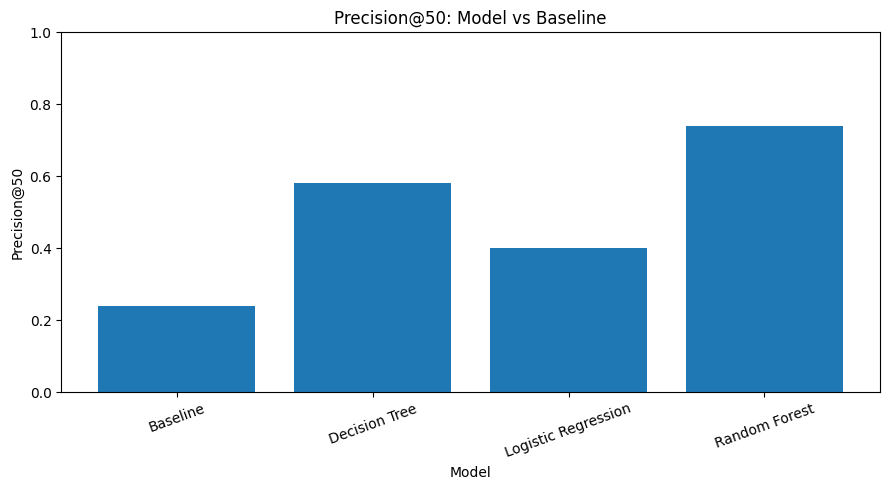

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Precision@50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Model")
plt.title("Precision@50: Model vs Baseline")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

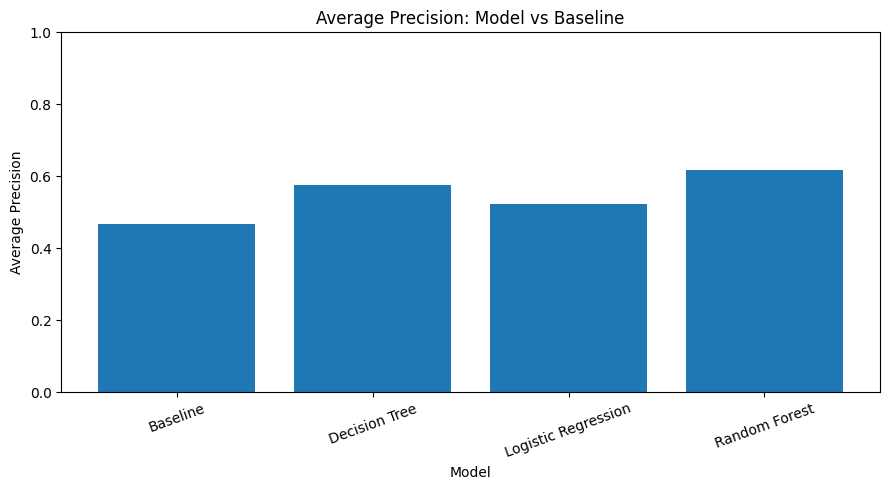

In [36]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Average Precision"]
)

plt.ylabel("Average Precision")
plt.xlabel("Model")
plt.title("Average Precision: Model vs Baseline")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [37]:
top_20 = ranked_queue[
    [
        "final_rank",
        "content_id",
        "best_model_probability",
        "confidence",
        "suggested_action",
        "final_reason_codes"
    ]
].head(20)

display(top_20)

,final_rank,content_id,best_model_probability,confidence,suggested_action,final_reason_codes
0,1,content_1f080331fa2b,0.782079,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...
1,2,content_6aa43079fb0c,0.788105,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
2,3,content_d6570c51c9bd,0.847372,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
3,4,content_72e800a9c214,0.774371,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
4,5,content_e04eb9549989,0.814805,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
5,6,content_b69288c5e701,0.795713,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
6,7,content_9b6df29f7889,0.846245,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
7,8,content_bb6ebb5ec8c8,0.834638,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
8,9,content_4d76cdb3387b,0.843092,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
9,10,content_b4f35d640b1c,0.843803,medium,refresh,declining_with_demand|model_decline_risk|visib...


In [38]:
top_20 = ranked_queue[
    [
        "final_rank",
        "content_id",
        "best_model_probability",
        "confidence",
        "suggested_action",
        "final_reason_codes"
    ]
].head(20)

display(top_20)

,final_rank,content_id,best_model_probability,confidence,suggested_action,final_reason_codes
0,1,content_1f080331fa2b,0.782079,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...
1,2,content_6aa43079fb0c,0.788105,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
2,3,content_d6570c51c9bd,0.847372,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
3,4,content_72e800a9c214,0.774371,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
4,5,content_e04eb9549989,0.814805,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
5,6,content_b69288c5e701,0.795713,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
6,7,content_9b6df29f7889,0.846245,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
7,8,content_bb6ebb5ec8c8,0.834638,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
8,9,content_4d76cdb3387b,0.843092,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...
9,10,content_b4f35d640b1c,0.843803,medium,refresh,declining_with_demand|model_decline_risk|visib...


In [40]:
action_counts = (
    ranked_queue["suggested_action"]
    .value_counts()
    .reset_index()
)

action_counts.columns = ["Suggested Action", "Count"]

display(action_counts)

,Suggested Action,Count
0,refresh_and_review_ctr,130
1,refresh,35
2,refresh_and_review_engagement,35


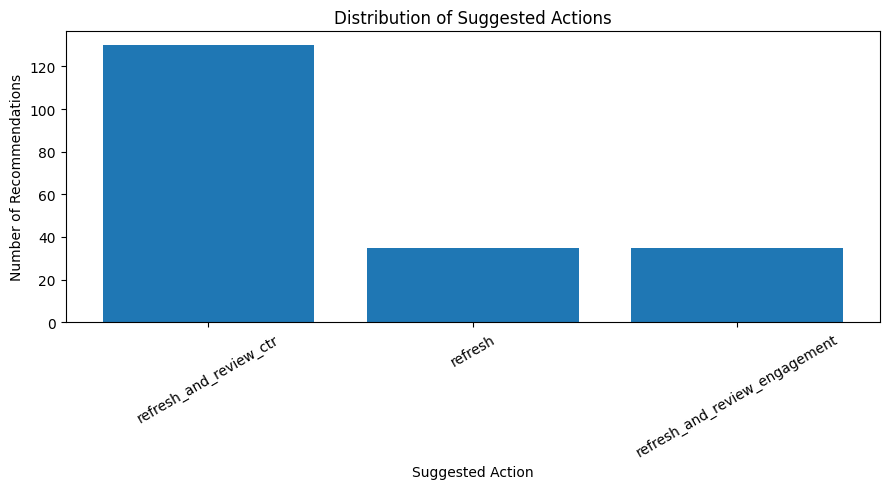

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    action_counts["Suggested Action"],
    action_counts["Count"]
)

plt.xlabel("Suggested Action")
plt.ylabel("Number of Recommendations")
plt.title("Distribution of Suggested Actions")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [42]:
from pathlib import Path

charts_dir = Path("outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

print("Charts directory:", charts_dir)

Charts directory: outputs/charts


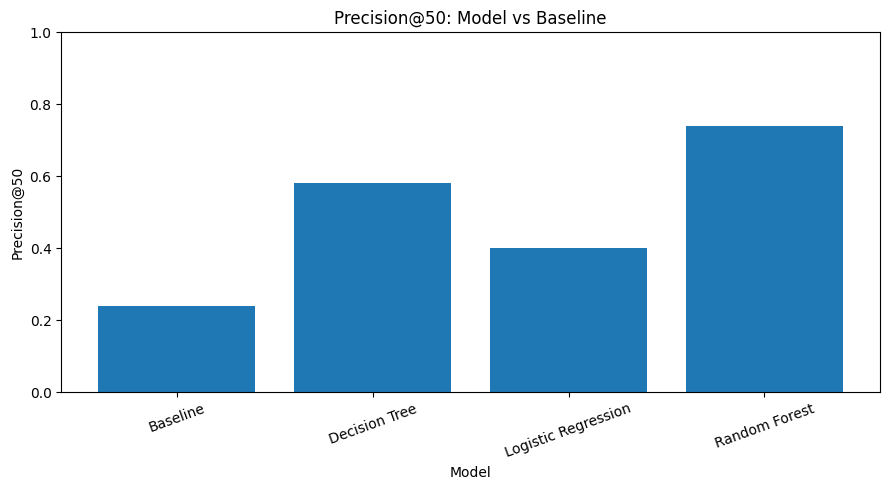

In [43]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Precision@50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Model")
plt.title("Precision@50: Model vs Baseline")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "outputs/charts/precision_at_50.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [44]:
comparison_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

print("Saved: outputs/model_comparison.csv")

Saved: outputs/model_comparison.csv


In [45]:
ranked_queue.to_csv(
    "outputs/ranked_recommendations.csv",
    index=False
)

print("Saved: outputs/ranked_recommendations.csv")

Saved: outputs/ranked_recommendations.csv


In [5]:
from pathlib import Path

charts_dir = Path("outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

print("Charts folder created:", charts_dir)

Charts folder created: outputs/charts


In [9]:
from pathlib import Path
import pandas as pd

# Create output folders
charts_dir = Path("outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

# Your actual capstone results
comparison_df = pd.DataFrame([
    {
        "Model": "Baseline",
        "Precision@50": 0.24,
        "ROC AUC": 0.6268917852237201,
        "Average Precision": 0.46760658636934826
    },
    {
        "Model": "Decision Tree",
        "Precision@50": 0.58,
        "ROC AUC": 0.7415203737887913,
        "Average Precision": 0.5753189989001579
    },
    {
        "Model": "Logistic Regression",
        "Precision@50": 0.40,
        "ROC AUC": 0.7002914980763613,
        "Average Precision": 0.5215418768632023
    },
    {
        "Model": "Random Forest",
        "Precision@50": 0.74,
        "ROC AUC": 0.7500295227262839,
        "Average Precision": 0.6182189675945409
    }
])

display(comparison_df)

,Model,Precision@50,ROC AUC,Average Precision
0,Baseline,0.24,0.626892,0.467607
1,Decision Tree,0.58,0.741520,0.575319
2,Logistic Regression,0.40,0.700291,0.521542
3,Random Forest,0.74,0.750030,0.618219


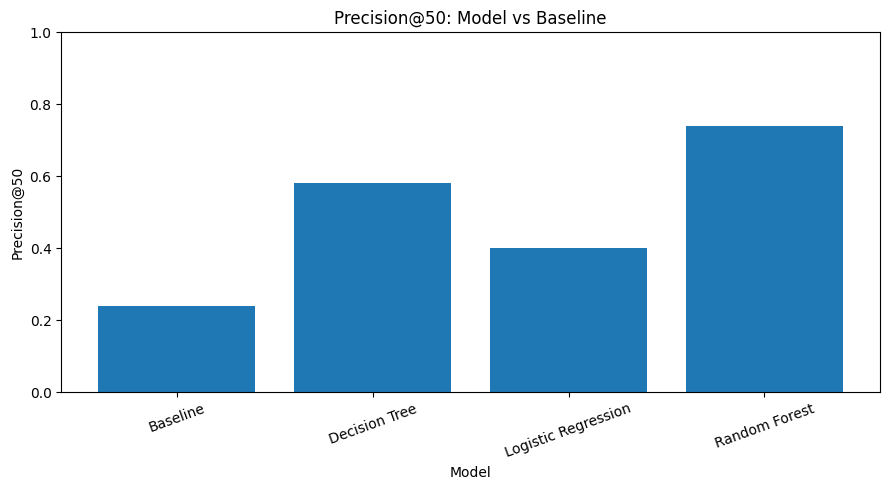

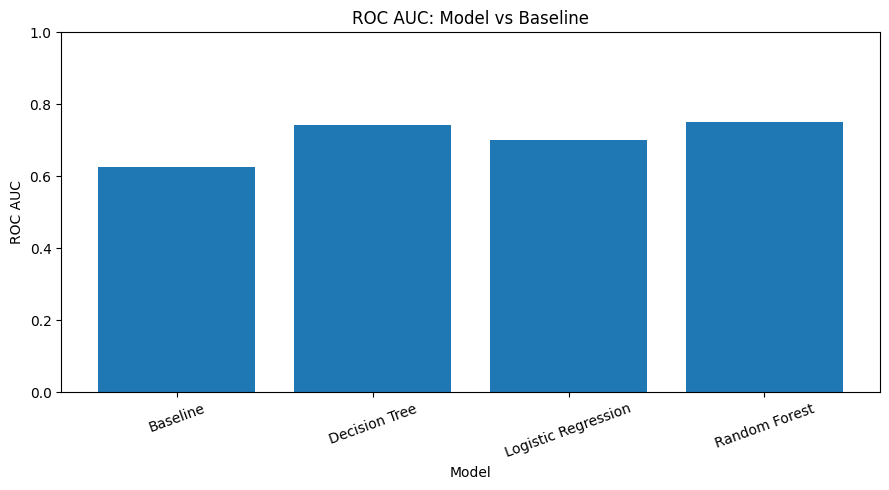

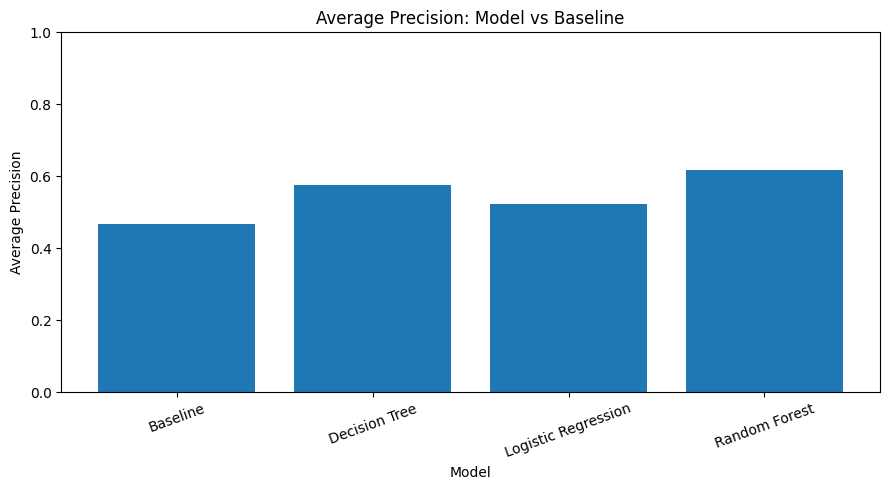

✅ All three charts created.


In [10]:
import matplotlib.pyplot as plt

# Precision@50
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["Precision@50"])
plt.xlabel("Model")
plt.ylabel("Precision@50")
plt.title("Precision@50: Model vs Baseline")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/charts/precision_at_50.png", dpi=200, bbox_inches="tight")
plt.show()


# ROC AUC
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["ROC AUC"])
plt.xlabel("Model")
plt.ylabel("ROC AUC")
plt.title("ROC AUC: Model vs Baseline")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/charts/roc_auc.png", dpi=200, bbox_inches="tight")
plt.show()


# Average Precision
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["Average Precision"])
plt.xlabel("Model")
plt.ylabel("Average Precision")
plt.title("Average Precision: Model vs Baseline")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/charts/average_precision.png", dpi=200, bbox_inches="tight")
plt.show()

print("✅ All three charts created.")

In [11]:
from pathlib import Path

print("Files currently available:")

for path in Path(".").rglob("*"):
    if path.is_file():
        print(path)

Files currently available:
.config/gce
.config/.last_opt_in_prompt.yaml
.config/config_sentinel
.config/active_config
.config/.last_update_check.json
.config/.last_survey_prompt.yaml
.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
.config/default_configs.db
sample_data/README.md
sample_data/anscombe.json
sample_data/california_housing_train.csv
sample_data/california_housing_test.csv
sample_data/mnist_train_small.csv
sample_data/mnist_test.csv
.config/configurations/config_default
.config/logs/2026.08.18/13.44.35.738632.log
.config/logs/2026.08.18/13.44.50.769621.log
.config/logs/2026.08.18/13.44.49.975155.log
.config/logs/2026.08.18/13.43.53.675741.log
.config/logs/2026.08.18/13.44.37.283866.log
.config/logs/2026.08.18/13.44.18.622222.log
outputs/charts/precision_at_50.png
outputs/charts/average_precision.png
outputs/charts/roc_auc.png


In [12]:
from pathlib import Path

paper_dir = Path("work/paper")
charts_dir = paper_dir / "charts"

charts_dir.mkdir(parents=True, exist_ok=True)

print("Created:")
print(paper_dir)
print(charts_dir)

Created:
work/paper
work/paper/charts


In [13]:
import shutil
from pathlib import Path

for chart in Path("outputs/charts").glob("*.png"):
    shutil.copy2(chart, Path("work/paper/charts") / chart.name)

print("Charts copied successfully!")

for chart in Path("work/paper/charts").glob("*.png"):
    print("✅", chart)

Charts copied successfully!
✅ work/paper/charts/precision_at_50.png
✅ work/paper/charts/average_precision.png
✅ work/paper/charts/roc_auc.png


In [14]:
from pathlib import Path

paper_file = Path("work/paper/index.html")

paper_file.touch()

print("Created:", paper_file)

Created: work/paper/index.html


In [15]:
from pathlib import Path

paper_dir = Path("/content/work/paper")
charts_dir = paper_dir / "charts"

charts_dir.mkdir(parents=True, exist_ok=True)

print("Paper folder:", paper_dir)
print("Charts folder:", charts_dir)

Paper folder: /content/work/paper
Charts folder: /content/work/paper/charts


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.